<a href="https://colab.research.google.com/github/gayun829/machine_learning_in_practice/blob/main/MLIP_w03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x = torch.ones(3,2)
print(x)

x2 = torch.zeros(3,2)
print(x2)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])
tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])


In [ ]:
torch.manual_seed(2)
x= torch.rand(3,2)
print(x)

x = torch.randn(3,3)
print(x)

tensor([[0.6147, 0.3810],
        [0.6371, 0.4745],
        [0.7136, 0.6190]])
tensor([[-2.1409, -0.5534, -0.5000],
        [-0.0815, -0.1633,  1.5277],
        [-0.4023,  0.0972, -0.5682]])


In [ ]:
x = torch.tensor([[1,2], [3,4], [5,6]])
print(x)
print(x[:,1])
print(x[0,:])

y = x[1,1]
print(y)

tensor([[1, 2],
        [3, 4],
        [5, 6]])
tensor([2, 4, 6])
tensor([1, 2])
tensor(4)


In [ ]:
x = torch.tensor([[1,2], [3,4], [5,6]])

y = x.view(2,3)
print(y)
y = x.view(6,-1)
print(y)

tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6]])


In [ ]:
x = torch.ones([3,2])
y = torch.ones([3,2])

# z = x+y
z = torch.add(x,y)
print(z)

# z = x-y
z = torch.sub(x,y)
print(z)
y.add_(x)
print(y)

tensor([[2., 2.],
        [2., 2.],
        [2., 2.]])
tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])
tensor([[2., 2.],
        [2., 2.],
        [2., 2.]])


In [ ]:
x = torch.linspace(0,1, steps=5)
x_np = x.numpy()
print(x)
print(type(x), type(x_np))

tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
<class 'torch.Tensor'> <class 'numpy.ndarray'>


In [ ]:
print(torch.cuda.device_count())

0


# 02 Linear model

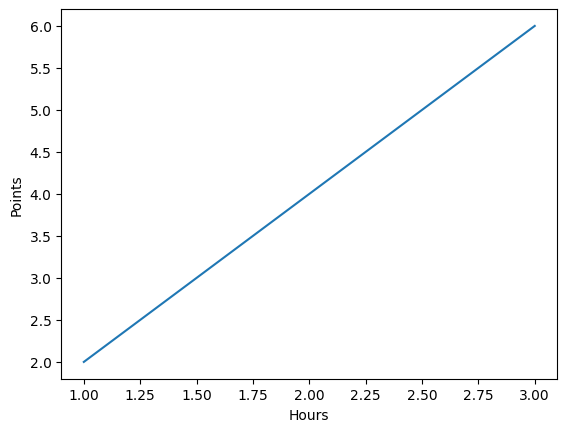

In [16]:
x_data = [1.0, 2.0, 3.0]
y_data = [2.0,4.0,6.0]

plt.plot(x_data, y_data)
plt.xlabel('Hours')
plt.ylabel('Points')
plt.show()

In [17]:
w = 1.0
def forward(x):
  return x * w

def loss(x,y):
  y_pred = forward(x)
  return (y_pred - y) * (y_pred-y)

In [ ]:
for w in np.arange(0.0, 4.1, 0.1):
  print("w=", w)
  l_sum = 0
  for x_val, y_val in zip(x_data, y_data):
    y_pred_val = forward(x_val)
    l = loss(x_val, y_val)
    l_sum += l
    print("\t", x_val, y_val, y_pred_val, l)
  print("MSE=", l_sum / 3)

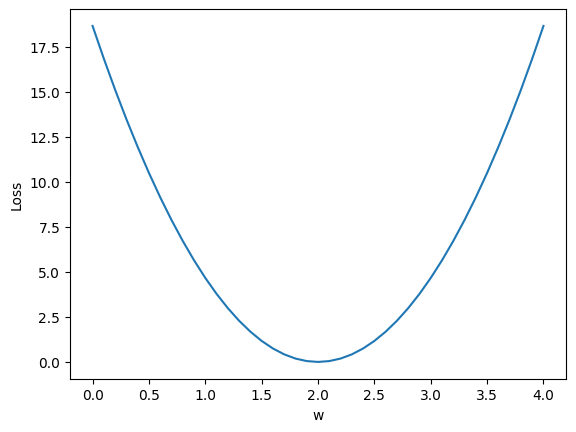

In [12]:
w_list = []
mse_list = []

for w in np.arange(0.0, 4.1, 0.1):
  l_sum = 0
  for x_val, y_val in zip(x_data, y_data):
    y_pred_val = forward(x_val)
    l = loss(x_val, y_val)
    l_sum += l

  w_list.append(w)
  mse_list.append(l_sum/3)

plt.plot(w_list, mse_list)
plt.ylabel('Loss')
plt.xlabel('w')
plt.show()

# 03 Gradient Descent


In [13]:
# comput gradient
def gradient(x, y):
  return 2 * x * (x*w-y)

In [18]:
print("predict (before training)", 4, forward(4))

# Training Loop
for epoch in range(100):
  for x_val, y_val in zip(x_data,y_data):
    grad = gradient(x_val, y_val)
    w = w - 0.01 * grad
    print("\tgrad: ", x_val, y_val, grad)
    l = loss(x_val, y_val)

  print("progress: ", epoch, "w=", w, "loss=", l)

# After training
print("predict (after training)", "4 hours", forward(4))

predict (before training) 4 4.0
	grad:  1.0 2.0 -2.0
	grad:  2.0 4.0 -7.84
	grad:  3.0 6.0 -16.2288
progress:  0 w= 1.260688 loss= 4.919240100095999
	grad:  1.0 2.0 -1.478624
	grad:  2.0 4.0 -5.796206079999999
	grad:  3.0 6.0 -11.998146585599997
progress:  1 w= 1.453417766656 loss= 2.688769240265834
	grad:  1.0 2.0 -1.093164466688
	grad:  2.0 4.0 -4.285204709416961
	grad:  3.0 6.0 -8.87037374849311
progress:  2 w= 1.5959051959019805 loss= 1.4696334962911515
	grad:  1.0 2.0 -0.8081896081960389
	grad:  2.0 4.0 -3.1681032641284723
	grad:  3.0 6.0 -6.557973756745939
progress:  3 w= 1.701247862192685 loss= 0.8032755585999681
	grad:  1.0 2.0 -0.59750427561463
	grad:  2.0 4.0 -2.3422167604093502
	grad:  3.0 6.0 -4.848388694047353
progress:  4 w= 1.7791289594933983 loss= 0.43905614881022015
	grad:  1.0 2.0 -0.44174208101320334
	grad:  2.0 4.0 -1.7316289575717576
	grad:  3.0 6.0 -3.584471942173538
progress:  5 w= 1.836707389300983 loss= 0.2399802903801062
	grad:  1.0 2.0 -0.3265852213980338
	gr